# Portafolio

## *How is Machine Learning Useful for Macroeconomic Forecasting?*

### Integrantes: Sergio Dominguez, Agustin Medina, Nicolas Melipil, Omar Zavala
### Profesor: Luis Cuevas

## 1. Resumen del Paper

### Referencia completa
Goulet Coulombe, P., Leroux, M., Stevanovic, D., & Surprenant, S. (2022).
How is machine learning useful for macroeconomic forecasting?
*Journal of Applied Econometrics*, 37(5), 920–964.
https://doi.org/10.1002/jae.2910

---

### Pregunta de investigación
El paper va más allá de la pregunta *"¿Es el Machine Learning útil para el
pronóstico macroeconómico?"* y se pregunta el **cómo**: ¿cuáles son las
características específicas de ML que explican sus ganancias sobre los métodos
macroeconométricos estándar?

Para responderla, los autores identifican **cuatro "tratamientos" o features de ML**:
1. **No linealidades (NL):** ¿Puede una función no lineal reducir el error de aproximación?
2. **Regularización (SH):** ¿Qué esquema de reducción de dimensionalidad es mejor?
3. **Validación cruzada (CV):** ¿Cómo seleccionar hiperparámetros óptimamente?
4. **Función de pérdida (LF):** ¿Ayuda usar una pérdida alternativa a la cuadrática (L2)?
5. **Pronósticos de Densidad**: ¿Son útiles las no linealidades de ML cuando se consideran pronósticos de densidad en lugar de pronósticos puntuales?

---

### Datos utilizados por los autores
- **Base de datos:** FRED-MD — panel mensual de 134 variables macroeconómicas
  y financieras de EE.UU., desde enero de 1960 hasta diciembre de 2017.
- **Variables objetivo (targets):** 5 indicadores representativos de la economía
  estadounidense:
  - `INDPRO` — Producción industrial (I(1), se predice tasa de crecimiento)
  - `UNRATE` — Tasa de desempleo (I(1), se predice cambio promedio)
  - `SPREAD` — Diferencial tasa 10Y vs tasa Fed funds (I(0), se predice nivel)
  - `INF` — Inflación CPI (I(1), se predice tasa de crecimiento)
  - `HOUST` — Inicios de construcción (I(1), se predice tasa de crecimiento)
- **Período de evaluación fuera de muestra:** enero 1980 — diciembre 2017
- **Horizontes de pronóstico:** h = 1, 3, 9, 12 y 24 meses

---

### Metodología
Los autores diseñan un experimento de pronóstico pseudo-fuera-de-muestra (POOS)
con ventana expandible, comparando más de 40 modelos que difieren únicamente en
una de las cuatro características arriba descritas. Esto permite identificar el
**efecto de tratamiento marginal** de cada feature de ML mediante regresiones
del tipo:

$$R^2_{t,h,v,m} = \dot{\alpha}^0_F \mathbf{1} + \dot{\psi}_{t,v,h} + \dot{u}_{t,h,v,m}$$

donde $R^2_{t,h,v,m}$ es el R² fuera de muestra del modelo $m$ para la variable
$v$ en el horizonte $h$ en el período $t$.

Los modelos base son:
- **AR** (data-poor): autoregresión directa solo con rezagos de la variable objetivo
- **ARDI** (data-rich): AR aumentado con índices de difusión (factores PCA de FRED-MD)

---

### Principales resultados y conclusiones
1. **Las no linealidades son el verdadero game changer:** mejoran
   sustancialmente el pronóstico para todas las variables, especialmente a
   horizontes largos. Las ganancias alcanzan hasta un 23% en R² fuera de muestra.
2. **El modelo de factores (ARDI/PCA) sigue siendo la mejor regularización:**
   los esquemas alternativos (Lasso, Ridge sobre datos crudos) no mejoran en
   promedio al modelo de factores estándar.
3. **K-fold CV es la mejor práctica:** supera a POOS-CV, especialmente en
   períodos de recesión.
4. **La función de pérdida ε-insensible del SVR no aporta:** las ganancias del
   SVR provienen del kernel trick (no linealidades), no de su función de pérdida
   alternativa.
5. Las ganancias de ML son mayores cuando la **incertidumbre macroeconómica
   es alta**, las **condiciones financieras son restrictivas** y durante
   **explosiones de burbujas inmobiliarias**.
6. Las no linealidades de ML (específicamente Quantile Random Forests)demuestran ser muy útiles al considerar **pronósticos de densidad**, superando significativamente a las alternativas lineales en el log score para casi todos los horizontes y variables.

---

### ¿Por qué elegimos este paper?
Este paper es relevante porque no solo aplica ML al pronóstico macroeconómico,
sino que lo hace de forma rigurosa y sistemática, descomponiendo las fuentes de
ganancia. Permite replicar una parte acotada del experimento (por ejemplo,
comparar Ridge, Lasso, ElasticNet y Random Forest sobre FRED-MD) con las
herramientas vistas en el curso, y proponer un modelo adicional (XGBoost) que
el paper no considera pero que es un benchmark estándar en la literatura reciente.

## 2. Datos

### Fuente
Se utiliza la base de datos **FRED-MD** (McCracken & Ng, 2016), el panel mensual
de referencia en la literatura de pronóstico macroeconómico. Está disponible
de forma pública y gratuita en el sitio web de la Reserva Federal de St. Louis.

La base contiene **134 series mensuales** de indicadores macroeconómicos y
financieros de EE.UU., organizadas en 8 grupos:
- Output y renta
- Labor market
- Housing
- Consumption, orders and inventories
- Money and credit
- Interest rates and exchange rates
- Prices
- Stock market

### Variables objetivo replicadas
Para esta réplica acotamos el análisis a **2 variables objetivo** y
**3 horizontes de pronóstico**, siguiendo el diseño del paper:

| Variable | Código FRED | Transformación | Descripción |
|---|---|---|---|
| `INDPRO` | INDPRO | Tasa de crecimiento (I(1)) | Producción industrial |
| `UNRATE` | UNRATE | Cambio promedio (I(1)) | Tasa de desempleo |

**Horizontes:** h = 1, 3 y 12 meses

### Proceso de obtención
Los datos se descargan directamente desde la URL oficial de FRED-MD en formato
CSV. Las transformaciones para inducir estacionariedad siguen el código de
transformación (`tcode`) incluido en la primera fila del archivo, tal como
indica McCracken & Ng (2016).

In [ ]:
# Instalación de dependencias
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost missingno --quiet

# Importación de bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model  import Ridge, Lasso, ElasticNet
from sklearn.ensemble       import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics         import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

pd.options.display.float_format = '{:.4f}'.format

In [ ]:
# Descarga FRED-MD desde la Fed de St. Louis
url_fred = 'https://www.stlouisfed.org/-/media/project/frbstl/stlouisfed/research/fred-md/monthly/current.csv'

# Leer el archivo — la primera fila contiene los tcodes de transformación
df_raw = pd.read_csv(url_fred, header=0)

# Separar los tcodes (primera fila de datos) del resto
tcodes     = df_raw.iloc[0].copy()
df_raw     = df_raw.iloc[1:].reset_index(drop=True)

# Convertir la columna de fechas a datetime y usarla como índice
df_raw['sasdate'] = pd.to_datetime(df_raw['sasdate'])
df_raw = df_raw.set_index('sasdate')

# Convertir todas las columnas a numéricas
df_raw = df_raw.apply(pd.to_numeric, errors='coerce')

print(f'Dataset descargado: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas')
print(f'Período: {df_raw.index.min().strftime("%Y-%m")} → {df_raw.index.max().strftime("%Y-%m")}')
df_raw.head(3)

Dataset descargado: 801 filas x 126 columnas
Período: 1959-01 → 2025-09


,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPDCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
sasdate,,,,,,,,,,,,,,,,,,,,,
1959-01-01,2583.5600,2426.0000,15.1880,276676.8154,17689.2397,21.9616,23.3868,22.2620,31.6664,18.9498,...,18.2940,10.1520,2.1300,2.4500,2.0400,NaN,6476.0000,12298.0000,84.2043,NaN
1959-02-01,2593.5960,2434.8000,15.3460,278713.9773,17819.0191,22.3917,23.7024,22.4549,31.8987,19.0492,...,18.3020,10.1670,2.1400,2.4600,2.0500,NaN,6476.0000,12298.0000,83.5280,NaN
1959-03-01,2610.3960,2452.7000,15.4910,277775.2539,17967.9134,22.7142,23.8459,22.5651,31.8987,19.4223,...,18.2890,10.1850,2.1500,2.4500,2.0700,NaN,6508.0000,12349.0000,81.6405,NaN


In [ ]:
# Función de transformaciones según tcode
def fn_aplicar_transformacion(serie, tcode):
    """
    Aplica la transformación correspondiente según McCracken & Ng (2016).
    input : serie (pd.Series), tcode (int)
    return: pd.Series transformada
    ---
    tcode 1 = nivel
    tcode 2 = primera diferencia
    tcode 3 = segunda diferencia
    tcode 4 = logaritmo
    tcode 5 = primera diferencia del logaritmo
    tcode 6 = segunda diferencia del logaritmo
    tcode 7 = primera diferencia del cociente logarítmico
    """
    tcode = int(float(tcode))
    if   tcode == 1: return serie
    elif tcode == 2: return serie.diff()
    elif tcode == 3: return serie.diff().diff()
    elif tcode == 4: return np.log(serie)
    elif tcode == 5: return np.log(serie).diff()
    elif tcode == 6: return np.log(serie).diff().diff()
    elif tcode == 7: return (serie / serie.shift(1) - 1).diff()
    else: return serie

# Aplicar transformaciones a todas las columnas según su tcode
df_trans = pd.DataFrame(index=df_raw.index)

for col in df_raw.columns:
    if col in tcodes.index:
        df_trans[col] = fn_aplicar_transformacion(df_raw[col], tcodes[col])

# Eliminar primeras filas con NaN producto de las diferencias
df_trans = df_trans.dropna(how='all').iloc[2:]

print(f'Dataset transformado: {df_trans.shape[0]} filas x {df_trans.shape[1]} columnas')
df_trans.head(3)

Dataset transformado: 799 filas x 126 columnas


,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPDCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
sasdate,,,,,,,,,,,,,,,,,,,,,
1959-03-01,0.0065,0.0073,0.0094,-0.0034,0.0083,0.0143,0.0060,0.0049,0.0000,0.0194,...,-0.0011,0.0003,-0.0000,-0.0081,0.0048,NaN,0.0049,0.0041,-0.0148,NaN
1959-04-01,0.0065,0.0070,-0.0036,0.0199,0.0006,0.0211,0.0143,0.0145,0.0157,0.0064,...,0.0013,0.0018,-0.0000,0.0122,-0.0049,NaN,0.0121,0.0067,0.0249,NaN
1959-05-01,0.0058,0.0066,0.0120,0.0068,0.0078,0.0150,0.0083,0.0096,0.0048,0.0202,...,-0.0017,-0.0019,-0.0000,-0.0041,-0.0048,NaN,0.0028,0.0020,-0.0153,NaN


In [ ]:
# Verificar que las variables objetivo estén disponibles
targets = ['INDPRO', 'UNRATE']

for t in targets:
    disponible = t in df_trans.columns
    print(f'{t}: {"✓ disponible" if disponible else "✗ no encontrada"}')

# Acotar el período al usado en el paper para el out-of-sample: 1980 en adelante
df_modelo = df_trans.loc['1960-01-01':].copy(deep=True)

print(f'\nPeríodo final del dataset: {df_modelo.index.min().strftime("%Y-%m")} → {df_modelo.index.max().strftime("%Y-%m")}')
print(f'Total de observaciones: {len(df_modelo)}')

INDPRO: ✓ disponible
UNRATE: ✓ disponible

Período final del dataset: 1960-01 → 2025-09
Total de observaciones: 789


In [ ]:
# Estadísticas descriptivas de las variables objetivo
print('Estadísticas descriptivas — Variables objetivo:')
df_modelo[targets].describe().round(4)

Estadísticas descriptivas — Variables objetivo:


,INDPRO,UNRATE
count,788.0000,788.0000
mean,0.0019,-0.0013
std,0.0096,0.4299
min,-0.1420,-2.2000
25%,-0.0018,-0.1000
50%,0.0023,0.0000
75%,0.0063,0.1000
max,0.0638,10.4000


In [ ]:
# Diagnóstico de valores faltantes
nulos_conteo = df_modelo.isna().sum()
nulos_pct    = (df_modelo.isna().mean() * 100).round(2)

df_nulos = pd.DataFrame({
    'nulos'      : nulos_conteo,
    'porcentaje' : nulos_pct
})

df_nulos = df_nulos[df_nulos['nulos'] > 0].sort_values('nulos', ascending=False)
print(f'Columnas con al menos un nulo: {len(df_nulos)}')
df_nulos.head(10)

Columnas con al menos un nulo: 84


,nulos,porcentaje
ACOGNO,388,49.1800
UMCSENTx,217,27.5000
TWEXAFEGSMTHx,157,19.9000
ANDENOx,99,12.5500
VIXCLSx,30,3.8000
ISRATIOx,2,0.2500
BUSINVx,2,0.2500
S&P PE ratio,2,0.2500
CMRMTSPLx,2,0.2500
CP3Mx,2,0.2500


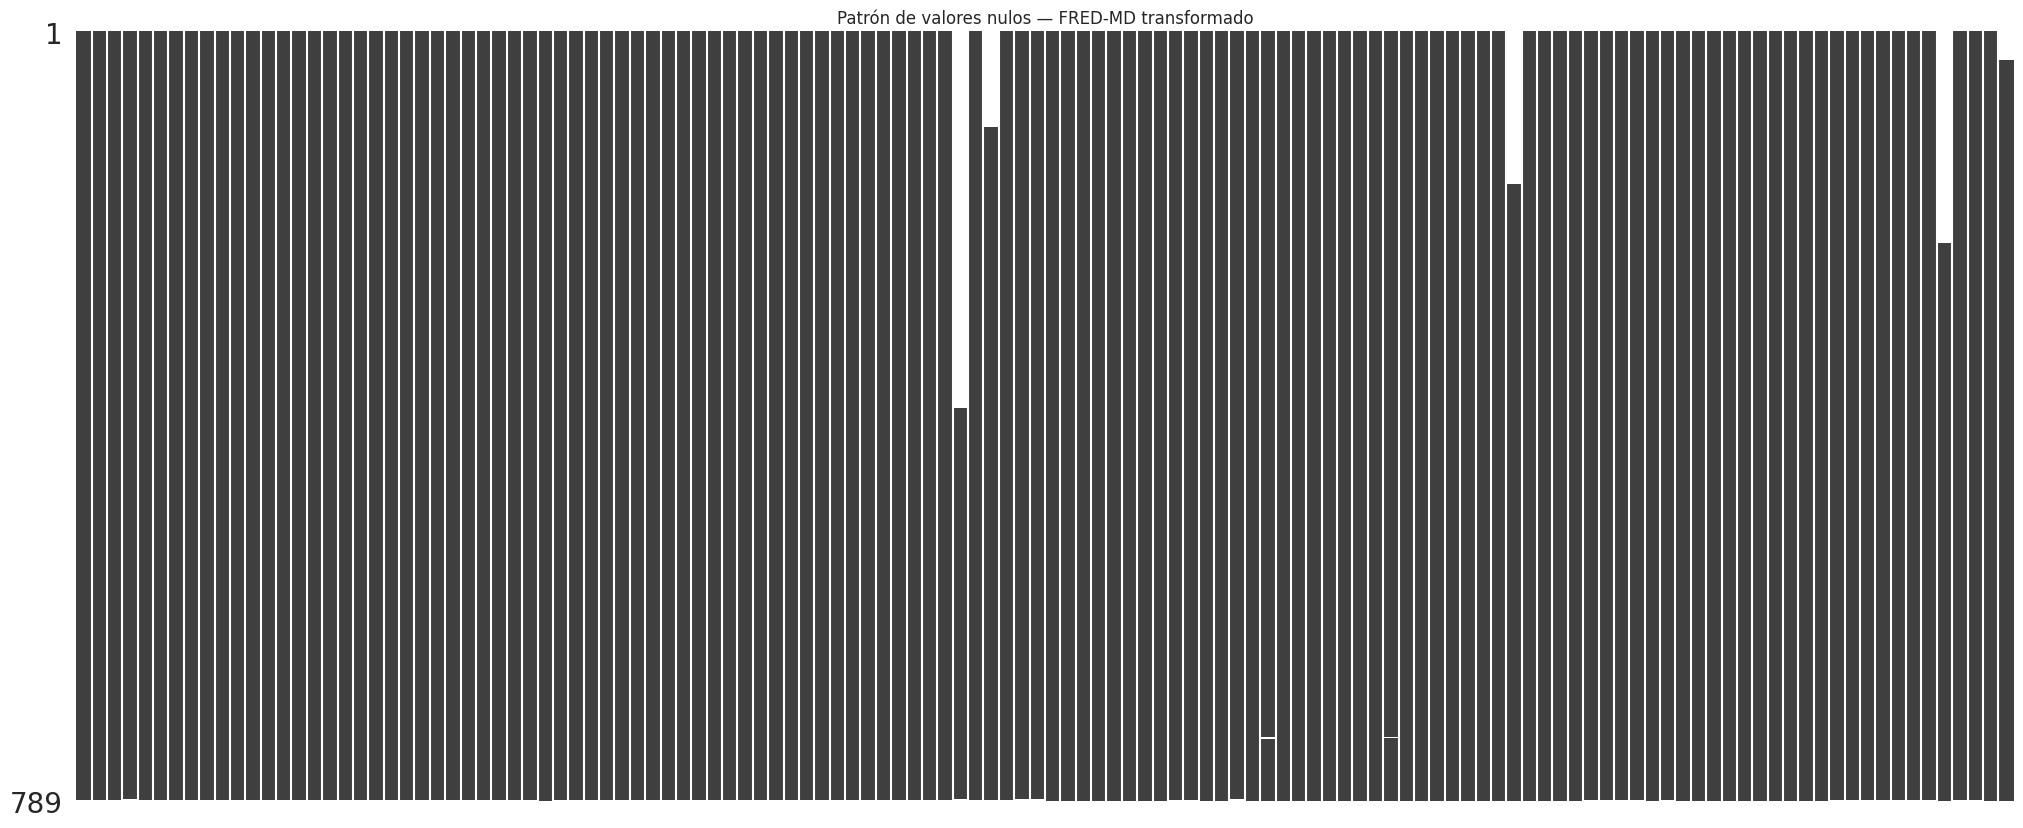

In [ ]:
# Visualización patrón de nulos
sns.set(rc={'figure.figsize': (14, 5)})
msno.matrix(df_modelo, sparkline=False)
plt.title('Patrón de valores nulos — FRED-MD transformado')
plt.show()

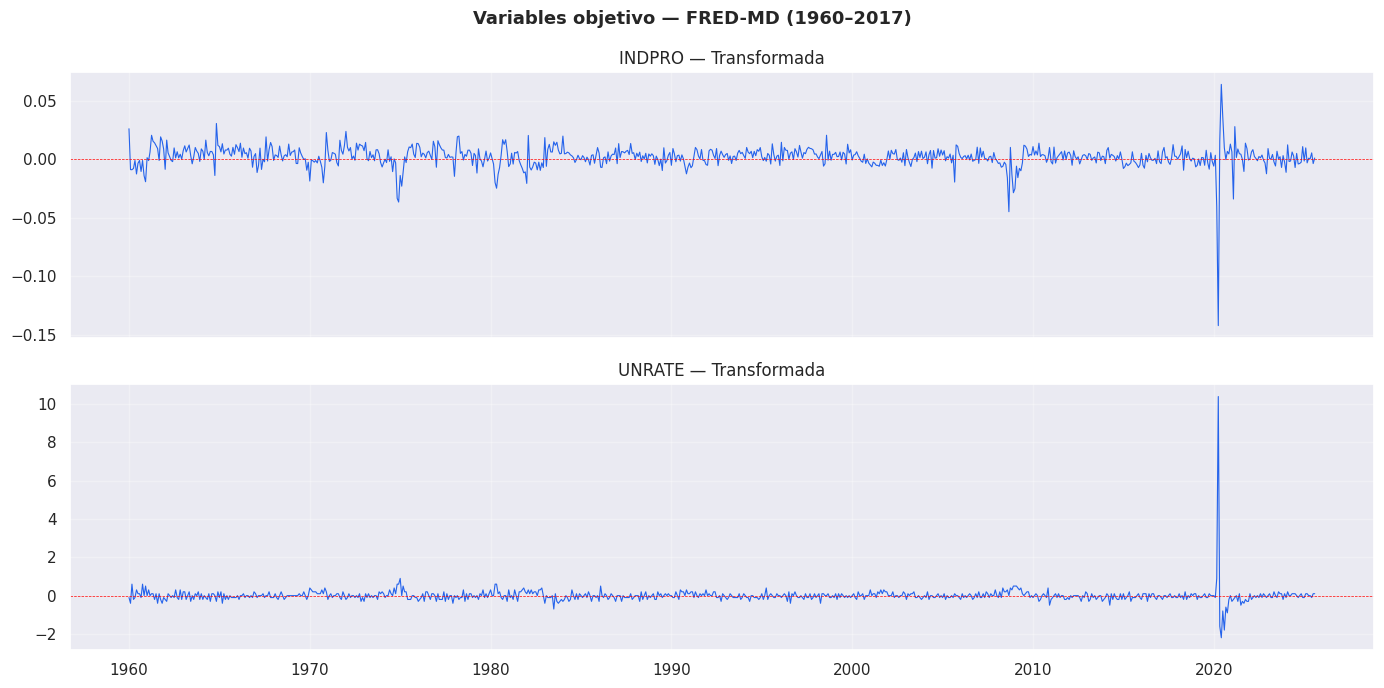

In [ ]:
# Evolución temporal de las variables objetivo
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for i, target in enumerate(targets):
    axes[i].plot(df_modelo.index, df_modelo[target], linewidth=0.8, color='#2563EB')
    axes[i].set_title(f'{target} — Transformada')
    axes[i].axhline(0, color='red', linestyle='--', linewidth=0.5)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Variables objetivo — FRED-MD (1960–2017)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

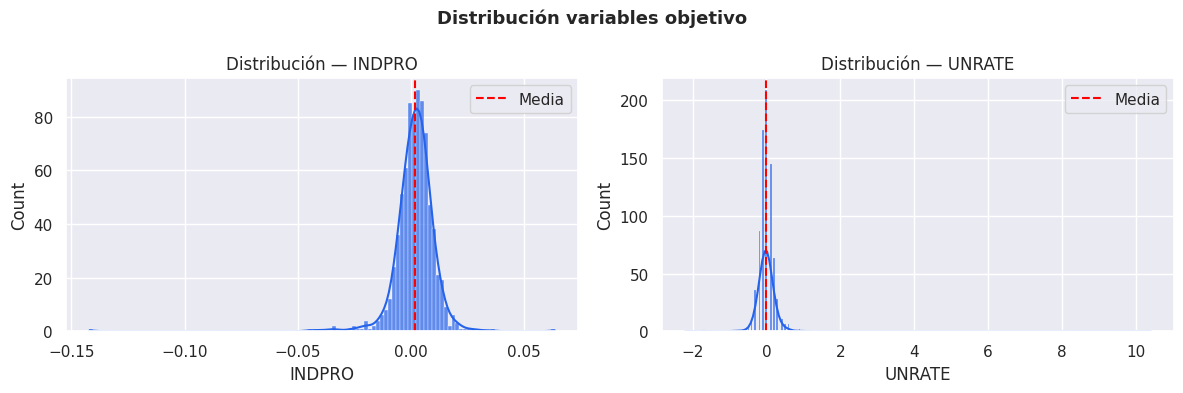

In [ ]:
# Distribución de las variables objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, target in enumerate(targets):
    sns.histplot(df_modelo[target].dropna(), kde=True, ax=axes[i],
                color='#2563EB', alpha=0.7)
    axes[i].set_title(f'Distribución — {target}')
    axes[i].axvline(df_modelo[target].mean(), color='red',
                   linestyle='--', label='Media')
    axes[i].legend()

plt.suptitle('Distribución variables objetivo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

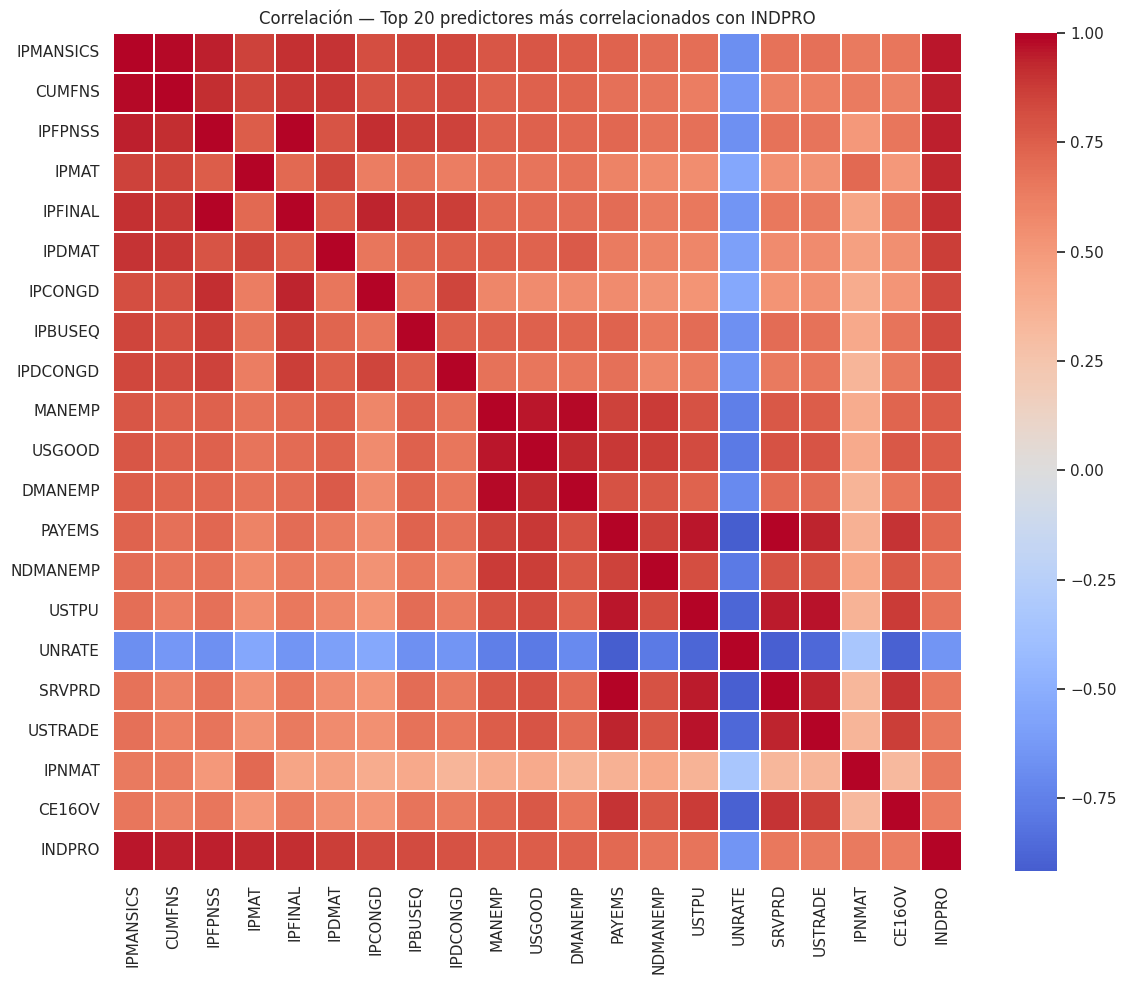

In [ ]:
# Mapa de calor de correlaciones (muestra de 20 variables)
# Seleccionamos las 20 variables con mayor correlación con INDPRO
cols_muestra = df_modelo.corr()['INDPRO'].abs().sort_values(ascending=False).iloc[1:21].index.tolist()

sns.set(rc={'figure.figsize': (12, 10)})
sns.heatmap(
    df_modelo[cols_muestra + ['INDPRO']].corr(),
    annot=False, cmap='coolwarm', center=0,
    linewidths=0.3
)
plt.title('Correlación — Top 20 predictores más correlacionados con INDPRO')
plt.tight_layout()
plt.show()

## 3. Preprocesamiento e Ingeniería de Atributos

El preprocesamiento sigue el diseño del paper original y consta de cuatro etapas:

### 3.1 Imputación de valores faltantes
FRED-MD presenta valores nulos en algunas series, especialmente al inicio del
panel. Se imputa con la **mediana de cada columna** (SimpleImputer), que es
robusta ante outliers — apropiado para series macroeconómicas que pueden tener
valores extremos en períodos de crisis.

### 3.2 Construcción del target h-pasos adelante
Siguiendo el paper, se usa **pronóstico directo**: el target $y_{t+h}$ se
construye desplazando h períodos hacia adelante la variable objetivo. Esto evita
la acumulación de errores del enfoque iterativo.

Para variables I(1) como INDPRO y UNRATE, el target es la **tasa de crecimiento
promedio** sobre el horizonte h:

$$y^{(h)}_{t+h} = \frac{1}{h} \ln\left(\frac{Y_{t+h}}{Y_t}\right)$$

### 3.3 Reducción de dimensionalidad — PCA (modelo ARDI)
El modelo de referencia del paper es el **ARDI** (Autoregression with Diffusion
Indices), que reemplaza las 134 variables de FRED-MD por sus primeros
**K factores principales (PCA)**. Esto sigue a Stock & Watson (2002).

El scaler se ajusta **solo con datos de entrenamiento** para evitar data leakage.

### 3.4 División train/test
El paper usa una **ventana expandible** con período fuera de muestra desde
1980M01. Para esta réplica simplificada usamos una división fija:
- **Train:** 1960 — 1999 (datos históricos)
- **Test:** 2000 — fin del dataset (evaluación fuera de muestra)

In [ ]:
# Imputación de valores faltantes con mediana
from sklearn.impute import SimpleImputer

copia = df_modelo.copy(deep=True)

# Imputar con mediana — robusto ante outliers en series macroeconómicas
imputer     = SimpleImputer(strategy='median')
arr_imp     = imputer.fit_transform(copia)
df_limpio   = pd.DataFrame(arr_imp, index=copia.index, columns=copia.columns)

print(f'Nulos antes de imputar : {copia.isna().sum().sum()}')
print(f'Nulos después de imputar: {df_limpio.isna().sum().sum()}')
df_limpio.head(3)

Nulos antes de imputar : 975
Nulos después de imputar: 0


,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPDCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
sasdate,,,,,,,,,,,,,,,,,,,,,
1960-01-01,0.0032,0.0047,0.0028,0.0170,0.0266,0.0259,0.0241,0.0290,0.0312,0.1038,...,-0.0018,-0.0012,-0.0047,0.0078,-0.0097,-0.1000,0.0043,-0.0117,-0.0133,17.6216
1960-02-01,0.0011,0.0009,0.0044,0.0144,0.0037,-0.0089,-0.0057,-0.0034,-0.0115,-0.0139,...,0.0017,0.0009,-0.0046,0.0039,-0.0048,-0.1000,0.0083,0.0054,-0.0189,17.6216
1960-03-01,0.0019,0.0009,0.0141,-0.0280,-0.0011,-0.0090,-0.0034,-0.0012,0.0012,-0.0200,...,0.0018,-0.0011,-0.0000,0.0301,-0.0047,-0.1000,0.0035,0.0010,0.0035,17.6216


In [ ]:
# Función para construir target h-pasos adelante
def fn_construir_target(df, variable, h):
    """
    Construye el target de pronóstico directo h períodos adelante.
    Siguiendo Stock & Watson (2002): tasa de crecimiento promedio sobre h.
    input : df (DataFrame), variable (str), h (int)
    return: pd.Series con el target desplazado h períodos
    """
    serie = df[variable].copy()
    # Tasa de crecimiento promedio: (1/h) * ln(Y_{t+h} / Y_t)
    # Como ya aplicamos log-diferencias, sumamos h rezagos y dividimos por h
    target = serie.rolling(h).sum().shift(-h) / h
    return target

# Construir targets para cada combinación variable x horizonte
horizontes = [1, 3, 12]

df_targets = pd.DataFrame(index=df_limpio.index)

for target in targets:
    for h in horizontes:
        col_name = f'{target}_h{h}'
        df_targets[col_name] = fn_construir_target(df_limpio, target, h)

print(f'Targets construidos: {list(df_targets.columns)}')
df_targets.head(5)

Targets construidos: ['INDPRO_h1', 'INDPRO_h3', 'INDPRO_h12', 'UNRATE_h1', 'UNRATE_h3', 'UNRATE_h12']


,INDPRO_h1,INDPRO_h3,INDPRO_h12,UNRATE_h1,UNRATE_h3,UNRATE_h12
sasdate,,,,,,
1960-01-01,-0.0089,-0.0086,-0.0074,-0.4000,0.0000,0.1167
1960-02-01,-0.0090,-0.0060,-0.0067,0.6000,0.1000,0.1750
1960-03-01,-0.0080,-0.0073,-0.0055,-0.2000,0.0000,0.1250
1960-04-01,-0.0011,-0.0058,-0.0031,-0.1000,0.1000,0.1500
1960-05-01,-0.0127,-0.0058,-0.0017,0.3000,0.1667,0.1667


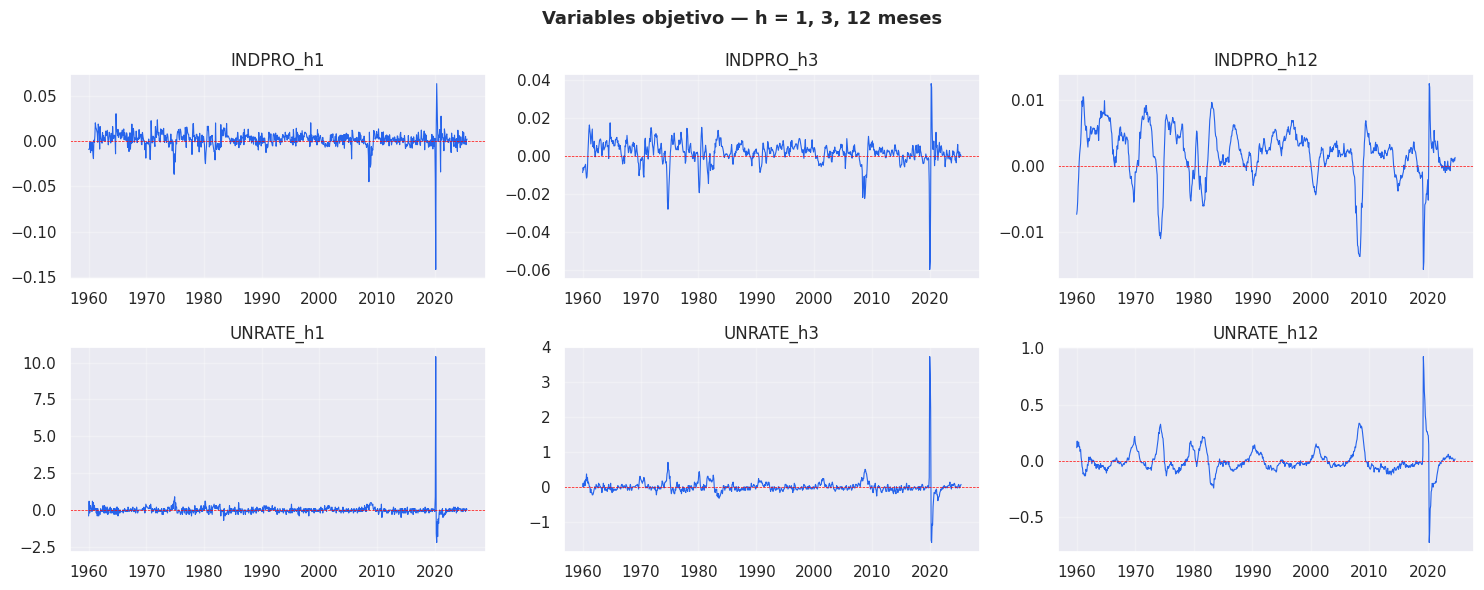

In [ ]:
# Visualizar los targets construidos
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes = axes.flatten()

for i, col in enumerate(df_targets.columns):
    axes[i].plot(df_targets.index, df_targets[col],
                linewidth=0.8, color='#2563EB')
    axes[i].set_title(col)
    axes[i].axhline(0, color='red', linestyle='--', linewidth=0.5)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Variables objetivo — h = 1, 3, 12 meses',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Función para construir el set de predictores ARDI
# ARDI = Autoregression augmented with Diffusion Indices (Stock & Watson, 2002)
def fn_construir_ardi(df, variable, h, n_factores=8, n_lags=3, train_end='1999-12-01'):
    """
    Construye el dataset X (predictores ARDI) e y (target) para un modelo.
    Aplica PCA solo con datos de entrenamiento para evitar data leakage.
    input : df (DataFrame), variable (str), h (int),
            n_factores (int), n_lags (int), train_end (str)
    return: X (DataFrame), y (Series), fechas_train, fechas_test
    """
    # Separar predictores (todas las columnas excepto los targets)
    cols_pred = [c for c in df.columns if c not in targets]
    X_raw     = df[cols_pred].copy(deep=True)

    # Construir target
    y = fn_construir_target(df, variable, h)

    # Separar índices train y test
    idx_train = X_raw.index[X_raw.index <= train_end]
    idx_test  = X_raw.index[X_raw.index >  train_end]

    # Escalar — fit SOLO en train
    scaler        = StandardScaler()
    X_train_std   = scaler.fit_transform(X_raw.loc[idx_train])
    X_test_std    = scaler.transform(X_raw.loc[idx_test])

    # PCA — fit SOLO en train (siguiendo el paper)
    pca           = PCA(n_components=n_factores)
    F_train       = pca.fit_transform(X_train_std)
    F_test        = pca.transform(X_test_std)

    # Crear DataFrames de factores
    cols_f    = [f'F{i+1}' for i in range(n_factores)]
    df_f_train = pd.DataFrame(F_train, index=idx_train, columns=cols_f)
    df_f_test  = pd.DataFrame(F_test,  index=idx_test,  columns=cols_f)
    df_factores = pd.concat([df_f_train, df_f_test])

    # Agregar rezagos de la variable objetivo (parte AR del ARDI)
    for lag in range(1, n_lags + 1):
        df_factores[f'{variable}_lag{lag}'] = df[variable].shift(lag)

    # Alinear X e y y eliminar NaN
    df_final = df_factores.join(y.rename('target')).dropna()

    X = df_final.drop(columns=['target'])
    y = df_final['target']

    fechas_train = X.index[X.index <= train_end]
    fechas_test  = X.index[X.index >  train_end]

    return X, y, fechas_train, fechas_test

print('Función fn_construir_ardi() definida correctamente.')
print('Parámetros: n_factores=8, n_lags=3, train_end=1999-12-01')

Función fn_construir_ardi() definida correctamente.
Parámetros: n_factores=8, n_lags=3, train_end=1999-12-01


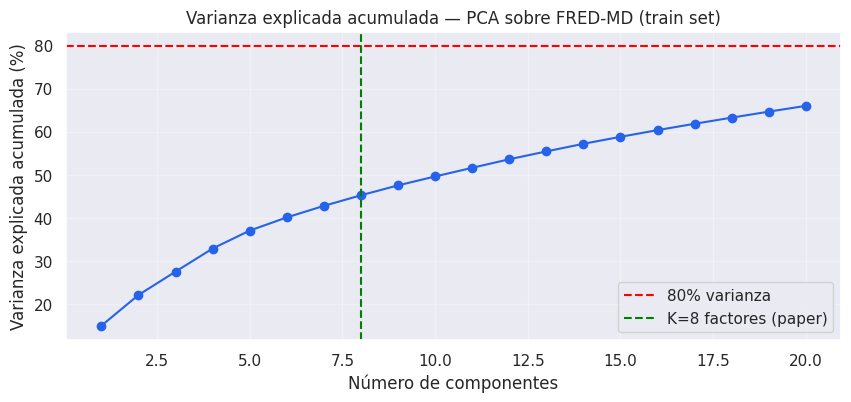

Varianza explicada con K=8 factores: 45.3%


In [ ]:
# Varianza explicada por los factores PCA
cols_pred  = [c for c in df_limpio.columns if c not in targets]
idx_train  = df_limpio.index[df_limpio.index <= '1999-12-01']

scaler_pca = StandardScaler()
X_std_pca  = scaler_pca.fit_transform(df_limpio.loc[idx_train, cols_pred])

pca_check  = PCA(n_components=20)
pca_check.fit(X_std_pca)

varianza_acum = np.cumsum(pca_check.explained_variance_ratio_) * 100

sns.set(rc={'figure.figsize': (10, 4)})
plt.figure()
plt.plot(range(1, 21), varianza_acum, marker='o', color='#2563EB')
plt.axhline(80, color='red', linestyle='--', label='80% varianza')
plt.axvline(8,  color='green', linestyle='--', label='K=8 factores (paper)')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada (%)')
plt.title('Varianza explicada acumulada — PCA sobre FRED-MD (train set)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f'Varianza explicada con K=8 factores: {varianza_acum[7]:.1f}%')

In [ ]:
# Construir todos los datasets X, y para cada combinación
# Resultado: diccionario con claves (variable, horizonte)

datos = {}

for variable in targets:
    for h in horizontes:
        X, y, fechas_train, fechas_test = fn_construir_ardi(
            df        = df_limpio,
            variable  = variable,
            h         = h,
            n_factores = 8,
            n_lags     = 3,
            train_end  = '1999-12-01'
        )

        X_train = X.loc[fechas_train]
        X_test  = X.loc[fechas_test]
        y_train = y.loc[fechas_train]
        y_test  = y.loc[fechas_test]

        datos[(variable, h)] = {
            'X_train' : X_train,
            'X_test'  : X_test,
            'y_train' : y_train,
            'y_test'  : y_test
        }

        print(f'{variable} h={h:2d} | Train: {len(X_train):3d} obs | Test: {len(X_test):3d} obs')

print(f'\nTotal de combinaciones preparadas: {len(datos)}')

INDPRO h= 1 | Train: 477 obs | Test: 308 obs
INDPRO h= 3 | Train: 477 obs | Test: 306 obs
INDPRO h=12 | Train: 477 obs | Test: 297 obs
UNRATE h= 1 | Train: 477 obs | Test: 308 obs
UNRATE h= 3 | Train: 477 obs | Test: 306 obs
UNRATE h=12 | Train: 477 obs | Test: 297 obs

Total de combinaciones preparadas: 6


## 4. Modelos del Paper

Se replican los modelos propuestos por Goulet Coulombe et al. (2022),
todos aplicados sobre el set de predictores ARDI construido en la Sección 3.

### Modelos implementados

| Modelo | Descripción | Hiperparámetros |
|---|---|---|
| **ARDI (baseline)** | Regresión lineal sobre factores PCA + rezagos AR | — |
| **Ridge** | Regularización L2 sobre ARDI | alpha ∈ {0.01, 0.1, 1, 10, 100} |
| **Lasso** | Regularización L1 sobre ARDI | alpha ∈ {0.001, 0.01, 0.1, 1, 10} |
| **ElasticNet** | Combinación L1 + L2 | alpha ∈ {0.001, 0.01, 0.1, 1}, l1_ratio ∈ {0.3, 0.5, 0.7, 0.9} |
| **Random Forest** | Ensamble no lineal de árboles | n_estimators=200, max_depth ∈ {3,5,7}, max_features ∈ {0.5, 0.7} |

### Metodología de validación
Siguiendo el paper, los hiperparámetros se seleccionan mediante
**K-Fold Cross Validation con K=10** sobre el conjunto de entrenamiento,
usando el MSE negativo como métrica de selección.

### Métricas de evaluación
- **RMSE** — métrica principal del paper (raíz del error cuadrático medio)
- **MAE** — error absoluto medio, robusto ante outliers
- **R²** — proporción de varianza explicada

In [ ]:
# Función central de métricas
def fn_metricas_info(modelo, y_verdadero, y_calculado):
    """
    Calcula métricas de regresión para evaluación de modelos.
    input : modelo (str), y_verdadero (array), y_calculado (array)
    return: DataFrame con MAE, RMSE, R2
    """
    metrics = {
        'MAE'  : mean_absolute_error(y_verdadero, y_calculado),
        'RMSE' : np.sqrt(mean_squared_error(y_verdadero, y_calculado)),
        'R2'   : r2_score(y_verdadero, y_calculado)
    }
    return pd.DataFrame(metrics, index=[modelo])

# Inicializar tabla acumuladora de resultados
df_resultados = pd.DataFrame()
print('fn_metricas_info() lista. df_resultados inicializado.')

fn_metricas_info() lista. df_resultados inicializado.


In [ ]:
# Modelo base: ARDI — Regresión Lineal sobre factores PCA
from sklearn.linear_model import LinearRegression

for (variable, h), sets in datos.items():

    X_train = sets['X_train']
    X_test  = sets['X_test']
    y_train = sets['y_train']
    y_test  = sets['y_test']

    # Instanciar y entrenar
    modelo_ardi = LinearRegression(fit_intercept=True)
    modelo_ardi.fit(X_train, y_train)

    # Predicciones en train y test
    y_train_pred = modelo_ardi.predict(X_train)
    y_test_pred  = modelo_ardi.predict(X_test)

    # Acumular métricas
    df_resultados = pd.concat([df_resultados,
        fn_metricas_info(f'ARDI_{variable}_h{h}_Train', y_train, y_train_pred),
        fn_metricas_info(f'ARDI_{variable}_h{h}_Test',  y_test,  y_test_pred)
    ])

print('Modelo ARDI (baseline) completado.')
df_resultados

Modelo ARDI (baseline) completado.


,MAE,RMSE,R2
ARDI_INDPRO_h1_Train,0.0047,0.0065,0.2805
ARDI_INDPRO_h1_Test,0.0060,0.0116,0.0122
ARDI_INDPRO_h3_Train,0.0033,0.0043,0.4140
ARDI_INDPRO_h3_Test,0.0044,0.0088,-0.4660
ARDI_INDPRO_h12_Train,0.0020,0.0025,0.5373
ARDI_INDPRO_h12_Test,0.0034,0.0049,-0.7580
ARDI_UNRATE_h1_Train,0.1240,0.1581,0.2489
ARDI_UNRATE_h1_Test,0.1847,0.6575,-0.0323
ARDI_UNRATE_h3_Train,0.0654,0.0870,0.4707
ARDI_UNRATE_h3_Test,0.1241,0.3895,-0.1375


In [ ]:
# Ridge — Regularización L2 con búsqueda de alpha
particiones   = KFold(n_splits=10, shuffle=True, random_state=0)
param_ridge   = {'alpha': [0.01, 0.1, 1, 10, 100]}

for (variable, h), sets in datos.items():

    X_train = sets['X_train']
    X_test  = sets['X_test']
    y_train = sets['y_train']
    y_test  = sets['y_test']

    # Búsqueda del mejor alpha
    grid_ridge = GridSearchCV(Ridge(), param_ridge,
                               cv=particiones,
                               scoring='neg_mean_squared_error')
    grid_ridge.fit(X_train, y_train)
    best_alpha = grid_ridge.best_params_['alpha']
    print(f'Ridge {variable} h={h} — mejor alpha: {best_alpha}')

    # Entrenar con mejor alpha
    modelo_ridge = Ridge(alpha=best_alpha, random_state=42)
    modelo_ridge.fit(X_train, y_train)

    y_train_pred = modelo_ridge.predict(X_train)
    y_test_pred  = modelo_ridge.predict(X_test)

    df_resultados = pd.concat([df_resultados,
        fn_metricas_info(f'Ridge_{variable}_h{h}_Train', y_train, y_train_pred),
        fn_metricas_info(f'Ridge_{variable}_h{h}_Test',  y_test,  y_test_pred)
    ])

print('Modelo Ridge completado.')

Ridge INDPRO h=1 — mejor alpha: 0.01
Ridge INDPRO h=3 — mejor alpha: 100
Ridge INDPRO h=12 — mejor alpha: 100
Ridge UNRATE h=1 — mejor alpha: 1
Ridge UNRATE h=3 — mejor alpha: 1
Ridge UNRATE h=12 — mejor alpha: 100
Modelo Ridge completado.


In [ ]:
# Lasso — Regularización L1 con búsqueda de alpha
param_lasso = {'alpha': [0.001, 0.01, 0.1, 1, 10]}

for (variable, h), sets in datos.items():

    X_train = sets['X_train']
    X_test  = sets['X_test']
    y_train = sets['y_train']
    y_test  = sets['y_test']

    grid_lasso = GridSearchCV(Lasso(), param_lasso,
                               cv=particiones,
                               scoring='neg_mean_squared_error')
    grid_lasso.fit(X_train, y_train)
    best_alpha = grid_lasso.best_params_['alpha']
    print(f'Lasso {variable} h={h} — mejor alpha: {best_alpha}')

    modelo_lasso = Lasso(alpha=best_alpha, random_state=42)
    modelo_lasso.fit(X_train, y_train)

    y_train_pred = modelo_lasso.predict(X_train)
    y_test_pred  = modelo_lasso.predict(X_test)

    df_resultados = pd.concat([df_resultados,
        fn_metricas_info(f'Lasso_{variable}_h{h}_Train', y_train, y_train_pred),
        fn_metricas_info(f'Lasso_{variable}_h{h}_Test',  y_test,  y_test_pred)
    ])

print('Modelo Lasso completado.')

Lasso INDPRO h=1 — mejor alpha: 0.001
Lasso INDPRO h=3 — mejor alpha: 0.001
Lasso INDPRO h=12 — mejor alpha: 0.001
Lasso UNRATE h=1 — mejor alpha: 0.001
Lasso UNRATE h=3 — mejor alpha: 0.001
Lasso UNRATE h=12 — mejor alpha: 0.001
Modelo Lasso completado.


In [ ]:
# ElasticNet — Combinación L1 + L2
param_en = {
    'alpha'    : [0.001, 0.01, 0.1, 1],
    'l1_ratio' : [0.3, 0.5, 0.7, 0.9]
}

for (variable, h), sets in datos.items():

    X_train = sets['X_train']
    X_test  = sets['X_test']
    y_train = sets['y_train']
    y_test  = sets['y_test']

    grid_en = GridSearchCV(ElasticNet(), param_en,
                            cv=particiones,
                            scoring='neg_mean_squared_error')
    grid_en.fit(X_train, y_train)
    best_params = grid_en.best_params_
    print(f'ElasticNet {variable} h={h} — {best_params}')

    modelo_en = ElasticNet(
        alpha     = best_params['alpha'],
        l1_ratio  = best_params['l1_ratio'],
        selection = 'random',
        random_state = 42
    )
    modelo_en.fit(X_train, y_train)

    y_train_pred = modelo_en.predict(X_train)
    y_test_pred  = modelo_en.predict(X_test)

    df_resultados = pd.concat([df_resultados,
        fn_metricas_info(f'ElasticNet_{variable}_h{h}_Train', y_train, y_train_pred),
        fn_metricas_info(f'ElasticNet_{variable}_h{h}_Test',  y_test,  y_test_pred)
    ])

print('Modelo ElasticNet completado.')

ElasticNet INDPRO h=1 — {'alpha': 0.001, 'l1_ratio': 0.3}
ElasticNet INDPRO h=3 — {'alpha': 0.001, 'l1_ratio': 0.3}
ElasticNet INDPRO h=12 — {'alpha': 0.001, 'l1_ratio': 0.3}
ElasticNet UNRATE h=1 — {'alpha': 0.001, 'l1_ratio': 0.3}
ElasticNet UNRATE h=3 — {'alpha': 0.001, 'l1_ratio': 0.3}
ElasticNet UNRATE h=12 — {'alpha': 0.001, 'l1_ratio': 0.3}
Modelo ElasticNet completado.


In [ ]:
# Random Forest — Modelo no lineal del paper
param_rf = {
    'max_depth'    : [3, 5, 7],
    'max_features' : [0.5, 0.7]
}

for (variable, h), sets in datos.items():

    X_train = sets['X_train']
    X_test  = sets['X_test']
    y_train = sets['y_train']
    y_test  = sets['y_test']

    grid_rf = GridSearchCV(
        RandomForestRegressor(n_estimators=200, random_state=42),
        param_rf,
        cv      = particiones,
        scoring = 'neg_mean_squared_error',
        n_jobs  = -1
    )
    grid_rf.fit(X_train, y_train)
    best_params = grid_rf.best_params_
    print(f'RF {variable} h={h} — {best_params}')

    modelo_rf = RandomForestRegressor(
        n_estimators = 200,
        max_depth    = best_params['max_depth'],
        max_features = best_params['max_features'],
        random_state = 42
    )
    modelo_rf.fit(X_train, y_train)

    y_train_pred = modelo_rf.predict(X_train)
    y_test_pred  = modelo_rf.predict(X_test)

    df_resultados = pd.concat([df_resultados,
        fn_metricas_info(f'RF_{variable}_h{h}_Train', y_train, y_train_pred),
        fn_metricas_info(f'RF_{variable}_h{h}_Test',  y_test,  y_test_pred)
    ])

print('Modelo Random Forest completado.')
df_resultados

RF INDPRO h=1 — {'max_depth': 7, 'max_features': 0.5}
RF INDPRO h=3 — {'max_depth': 7, 'max_features': 0.7}
RF INDPRO h=12 — {'max_depth': 7, 'max_features': 0.5}
RF UNRATE h=1 — {'max_depth': 5, 'max_features': 0.7}
RF UNRATE h=3 — {'max_depth': 7, 'max_features': 0.5}
RF UNRATE h=12 — {'max_depth': 7, 'max_features': 0.5}
Modelo Random Forest completado.


,MAE,RMSE,R2
ARDI_INDPRO_h1_Train,0.0047,0.0065,0.2805
ARDI_INDPRO_h1_Test,0.0060,0.0116,0.0122
ARDI_INDPRO_h3_Train,0.0033,0.0043,0.4140
ARDI_INDPRO_h3_Test,0.0044,0.0088,-0.4660
ARDI_INDPRO_h12_Train,0.0020,0.0025,0.5373
ARDI_INDPRO_h12_Test,0.0034,0.0049,-0.7580
ARDI_UNRATE_h1_Train,0.1240,0.1581,0.2489
ARDI_UNRATE_h1_Test,0.1847,0.6575,-0.0323
ARDI_UNRATE_h3_Train,0.0654,0.0870,0.4707
ARDI_UNRATE_h3_Test,0.1241,0.3895,-0.1375


In [ ]:
# Verificar tabla de resultados acumulada hasta aquí
print(f'Modelos registrados: {len(df_resultados)}')
print(f'Combinaciones variables x horizontes: {len(datos)}')

# Mostrar solo filas de Test para comparación rápida
mask_test = df_resultados.index.str.contains('Test')
print('\nResumen — métricas en Test set:')
df_resultados[mask_test].sort_index()

Modelos registrados: 60
Combinaciones variables x horizontes: 6

Resumen — métricas en Test set:


,MAE,RMSE,R2
ARDI_INDPRO_h12_Test,0.0034,0.0049,-0.7580
ARDI_INDPRO_h1_Test,0.0060,0.0116,0.0122
ARDI_INDPRO_h3_Test,0.0044,0.0088,-0.4660
ARDI_UNRATE_h12_Test,0.0793,0.1482,0.0034
ARDI_UNRATE_h1_Test,0.1847,0.6575,-0.0323
ARDI_UNRATE_h3_Test,0.1241,0.3895,-0.1375
ElasticNet_INDPRO_h12_Test,0.0034,0.0047,-0.5922
ElasticNet_INDPRO_h1_Test,0.0059,0.0116,0.0078
ElasticNet_INDPRO_h3_Test,0.0042,0.0086,-0.4113
ElasticNet_UNRATE_h12_Test,0.0798,0.1473,0.0157


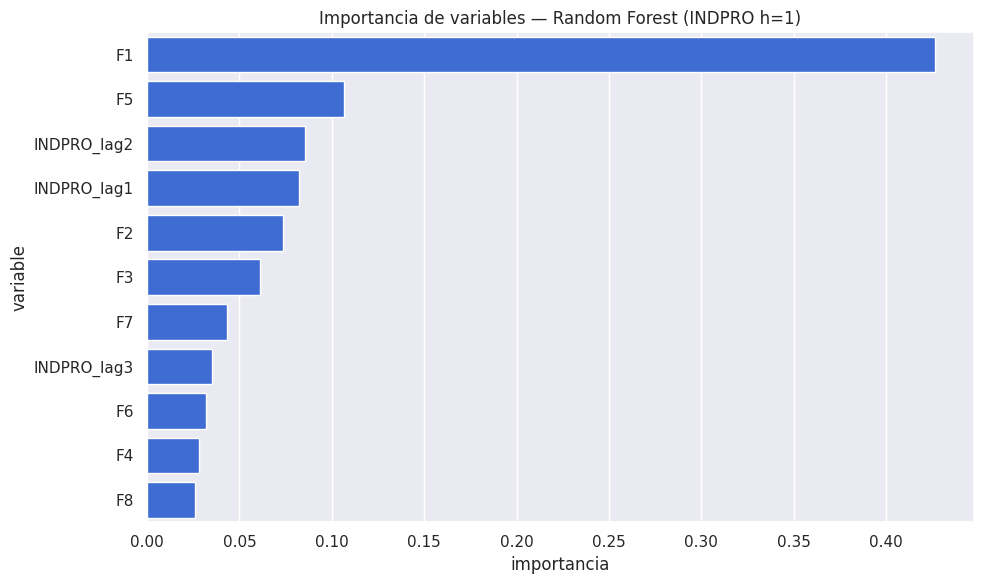

In [ ]:
# Importancia de variables del Random Forest (INDPRO h=1)
# Re-entrenar el RF para INDPRO h=1 para extraer feature importances
sets_ejemplo = datos[('INDPRO', 1)]
X_tr = sets_ejemplo['X_train']
y_tr = sets_ejemplo['y_train']

modelo_rf_ex = RandomForestRegressor(
    n_estimators=200, max_depth=5,
    max_features=0.7, random_state=42
)
modelo_rf_ex.fit(X_tr, y_tr)

importancias = pd.DataFrame({
    'variable'    : X_tr.columns,
    'importancia' : modelo_rf_ex.feature_importances_
}).sort_values('importancia', ascending=False)

sns.set(rc={'figure.figsize': (10, 6)})
sns.barplot(data=importancias, x='importancia', y='variable', color='#2563EB')
plt.title('Importancia de variables — Random Forest (INDPRO h=1)')
plt.tight_layout()
plt.show()

## 5. Modelo Adicional Propuesto — XGBoost

### Justificación de la elección

El paper original (Goulet Coulombe et al., 2022) compara modelos lineales
regularizados (Ridge, Lasso, ElasticNet) contra Random Forest y Kernel Ridge
Regression como representantes de las no linealidades. **XGBoost no es
considerado en el paper**, a pesar de ser hoy uno de los algoritmos de
ensamble más utilizados tanto en la industria como en la literatura reciente
de pronóstico macroeconómico y financiero.

Se elige XGBoost como modelo adicional por tres razones:

1. **Boosting secuencial vs Bagging**: a diferencia del Random Forest del
   paper (que promedia árboles independientes construidos en paralelo),
   XGBoost construye árboles de forma **secuencial**, donde cada árbol
   corrige los residuos del árbol anterior mediante descenso de gradiente.
   Esto permite comparar dos filosofías de ensamble distintas sobre los
   mismos datos.

2. **Regularización integrada**: XGBoost incorpora penalización L1 y L2
   directamente en su función de costos, lo que lo conecta conceptualmente
   con el "Feature 2: Regularization" del paper, pero aplicado sobre un
   modelo no lineal en vez de uno lineal.

3. **Benchmark estándar no considerado por los autores**: es el algoritmo
   dominante en competencias de pronóstico (Kaggle, M5, M6) y un benchmark
   de facto en la literatura de ML aplicado a series económicas y
   financieras posterior a 2022.

### Metodología
Se replica el mismo protocolo del paper: los mismos sets X_train/X_test
de la Sección 3 (factores ARDI + rezagos), la misma validación K-Fold (K=10)
con random_state=0 para garantizar reproducibilidad, y las mismas métricas
(RMSE, MAE, R²).

In [ ]:
# Modelo adicional: XGBoost Regressor
from xgboost import XGBRegressor

# Hiperparámetros a explorar (mismos rangos vistos en clase)
param_xgb = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [3, 4, 5],
    'learning_rate'    : [0.05, 0.1, 0.2],
    'subsample'        : [0.8, 1.0],
    'colsample_bytree' : [0.8, 1.0]
}

for (variable, h), sets in datos.items():

    X_train = sets['X_train']
    X_test  = sets['X_test']
    y_train = sets['y_train']
    y_test  = sets['y_test']

    # Búsqueda de hiperparámetros con K-Fold (K=10, reproducible)
    grid_xgb = GridSearchCV(
        estimator  = XGBRegressor(random_state=0, n_jobs=-1),
        param_grid = param_xgb,
        cv         = particiones,
        scoring    = 'neg_mean_squared_error',
        n_jobs     = -1
    )

    # XGBoost no requiere escalado (basado en árboles)
    grid_xgb.fit(X_train, y_train)
    best_params = grid_xgb.best_params_
    print(f'XGBoost {variable} h={h} — mejor configuración: {best_params}')

    # Entrenar modelo final con mejores hiperparámetros
    modelo_xgb = XGBRegressor(
        n_estimators     = best_params['n_estimators'],
        max_depth        = best_params['max_depth'],
        learning_rate    = best_params['learning_rate'],
        subsample        = best_params['subsample'],
        colsample_bytree = best_params['colsample_bytree'],
        random_state     = 0,
        n_jobs           = -1
    )
    modelo_xgb.fit(X_train, y_train)

    # Predicciones en train y test
    y_train_pred = modelo_xgb.predict(X_train)
    y_test_pred  = modelo_xgb.predict(X_test)

    # Acumular métricas
    df_resultados = pd.concat([df_resultados,
        fn_metricas_info(f'XGBoost_{variable}_h{h}_Train', y_train, y_train_pred),
        fn_metricas_info(f'XGBoost_{variable}_h{h}_Test',  y_test,  y_test_pred)
    ])

print(f'\nModelo XGBoost completado — {len(datos)} combinaciones procesadas.')
df_resultados

XGBoost INDPRO h=1 — mejor configuración: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
XGBoost INDPRO h=3 — mejor configuración: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
XGBoost INDPRO h=12 — mejor configuración: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}
XGBoost UNRATE h=1 — mejor configuración: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
XGBoost UNRATE h=3 — mejor configuración: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
XGBoost UNRATE h=12 — mejor configuración: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

Modelo XGBoost completado — 6 combinaciones procesadas.


,MAE,RMSE,R2
ARDI_INDPRO_h1_Train,0.0047,0.0065,0.2805
ARDI_INDPRO_h1_Test,0.0060,0.0116,0.0122
ARDI_INDPRO_h3_Train,0.0033,0.0043,0.4140
ARDI_INDPRO_h3_Test,0.0044,0.0088,-0.4660
ARDI_INDPRO_h12_Train,0.0020,0.0025,0.5373
...,...,...,...
XGBoost_UNRATE_h1_Test,0.1710,0.6241,0.0700
XGBoost_UNRATE_h3_Train,0.0484,0.0623,0.7285
XGBoost_UNRATE_h3_Test,0.1180,0.3555,0.0523
XGBoost_UNRATE_h12_Train,0.0288,0.0382,0.7961


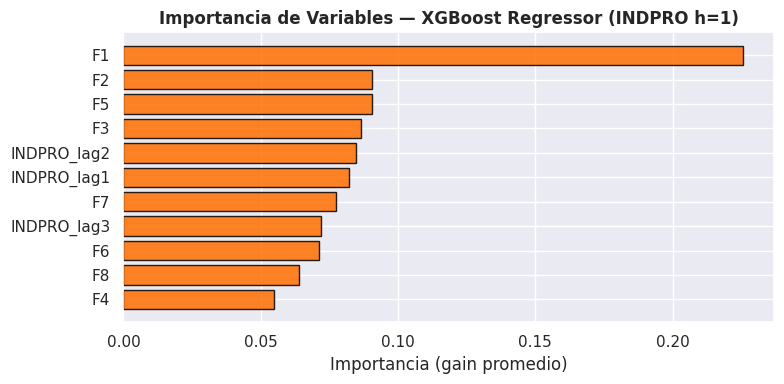

In [ ]:
# Importancia de variables — XGBoost (INDPRO h=1)
sets_ejemplo  = datos[('INDPRO', 1)]
X_tr          = sets_ejemplo['X_train']
y_tr          = sets_ejemplo['y_train']

modelo_xgb_ex = XGBRegressor(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=0, n_jobs=-1
)
modelo_xgb_ex.fit(X_tr, y_tr)

imp_xgb = pd.DataFrame({
    'Variable'    : X_tr.columns,
    'Importancia' : modelo_xgb_ex.feature_importances_
}).sort_values('Importancia', ascending=True)

fig, ax = plt.subplots(figsize=(8, max(4, len(imp_xgb) * 0.35)))
ax.barh(imp_xgb['Variable'], imp_xgb['Importancia'],
        color='#FF6F00', edgecolor='black', alpha=0.85)
ax.set_title('Importancia de Variables — XGBoost Regressor (INDPRO h=1)',
             fontweight='bold')
ax.set_xlabel('Importancia (gain promedio)')
plt.tight_layout()
plt.show()

In [ ]:
# Comparación directa Random Forest vs XGBoost en Test set
mask_ensambles = (
    df_resultados.index.str.contains('Test') &
    (df_resultados.index.str.startswith('RF') |
     df_resultados.index.str.startswith('XGBoost'))
)

df_ensambles = df_resultados[mask_ensambles].sort_index()
print('Bagging (Random Forest) vs Boosting (XGBoost) — Test set:')
df_ensambles

Bagging (Random Forest) vs Boosting (XGBoost) — Test set:


,MAE,RMSE,R2
RF_INDPRO_h12_Test,0.0031,0.0044,-0.4165
RF_INDPRO_h1_Test,0.0056,0.0111,0.0962
RF_INDPRO_h3_Test,0.0041,0.0074,-0.0427
RF_UNRATE_h12_Test,0.0828,0.1442,0.0560
RF_UNRATE_h1_Test,0.1723,0.6223,0.0754
RF_UNRATE_h3_Test,0.1183,0.3588,0.0349
XGBoost_INDPRO_h12_Test,0.0032,0.0045,-0.4527
XGBoost_INDPRO_h1_Test,0.0056,0.0110,0.1043
XGBoost_INDPRO_h3_Test,0.0041,0.0074,-0.0204
XGBoost_UNRATE_h12_Test,0.0821,0.1423,0.0803


## 6. Comparación de Resultados

En esta sección se comparan los 5 modelos implementados — los 4 del paper
(ARDI, Ridge, Lasso, ElasticNet, Random Forest) más el modelo adicional
propuesto (XGBoost) — usando las métricas RMSE, MAE y R² sobre el conjunto
de prueba (Test), para las 2 variables objetivo (INDPRO, UNRATE) y los 3
horizontes de pronóstico (h = 1, 3, 12).

La métrica principal de comparación es el **RMSE**, siguiendo la práctica
estándar del paper original.

In [ ]:
# Reestructurar df_resultados en formato largo (long format)
# El índice tiene el formato: Modelo_Variable_hH_Set (ej: 'Ridge_INDPRO_h1_Test')

df_largo = df_resultados.copy(deep=True)
df_largo = df_largo.reset_index().rename(columns={'index': 'etiqueta'})

# Separar la etiqueta en sus componentes
partes = df_largo['etiqueta'].str.split('_', expand=True)
df_largo['Modelo']    = partes[0]
df_largo['Variable']  = partes[1]
df_largo['Horizonte'] = partes[2].str.replace('h', '').astype(int)
df_largo['Set']       = partes[3]

df_largo = df_largo[['Modelo', 'Variable', 'Horizonte', 'Set', 'MAE', 'RMSE', 'R2']]

print(f'Total de filas reestructuradas: {len(df_largo)}')
df_largo.head(10)

Total de filas reestructuradas: 72


,Modelo,Variable,Horizonte,Set,MAE,RMSE,R2
0,ARDI,INDPRO,1,Train,0.0047,0.0065,0.2805
1,ARDI,INDPRO,1,Test,0.0060,0.0116,0.0122
2,ARDI,INDPRO,3,Train,0.0033,0.0043,0.4140
3,ARDI,INDPRO,3,Test,0.0044,0.0088,-0.4660
4,ARDI,INDPRO,12,Train,0.0020,0.0025,0.5373
5,ARDI,INDPRO,12,Test,0.0034,0.0049,-0.7580
6,ARDI,UNRATE,1,Train,0.1240,0.1581,0.2489
7,ARDI,UNRATE,1,Test,0.1847,0.6575,-0.0323
8,ARDI,UNRATE,3,Train,0.0654,0.0870,0.4707
9,ARDI,UNRATE,3,Test,0.1241,0.3895,-0.1375


In [ ]:
# Tabla comparativa: RMSE en Test por modelo, variable y horizonte
df_test = df_largo[df_largo['Set'] == 'Test'].copy(deep=True)

tabla_rmse = df_test.pivot_table(
    index   = ['Variable', 'Horizonte'],
    columns = 'Modelo',
    values  = 'RMSE'
).round(4)

# Reordenar columnas en orden lógico
orden_modelos = ['ARDI', 'Ridge', 'Lasso', 'ElasticNet', 'RF', 'XGBoost']
tabla_rmse = tabla_rmse[[c for c in orden_modelos if c in tabla_rmse.columns]]

print('Tabla comparativa — RMSE en Test set:')
tabla_rmse

Tabla comparativa — RMSE en Test set:


Modelo               ARDI  Ridge  Lasso  ElasticNet     RF  XGBoost
Variable Horizonte                                                 
INDPRO   1         0.0116 0.0116 0.0117      0.0116 0.0111   0.0110
         3         0.0088 0.0092 0.0087      0.0086 0.0074   0.0074
         12        0.0049 0.0050 0.0047      0.0047 0.0044   0.0045
UNRATE   1         0.6575 0.6563 0.6526      0.6554 0.6223   0.6241
         3         0.3895 0.3876 0.3813      0.3858 0.3588   0.3555
         12        0.1482 0.1473 0.1469      0.1473 0.1442   0.1423

In [ ]:
# Identificar el mejor modelo (menor RMSE) para cada variable-horizonte
mejor_modelo = tabla_rmse.idxmin(axis=1)

df_mejor = pd.DataFrame({'Mejor_Modelo': mejor_modelo})
print('Mejor modelo (menor RMSE) por variable y horizonte:')
df_mejor

# Aplicar formato visual: resaltar el mínimo de cada fila
tabla_rmse.style.highlight_min(axis=1, color='lightgreen')

Mejor modelo (menor RMSE) por variable y horizonte:


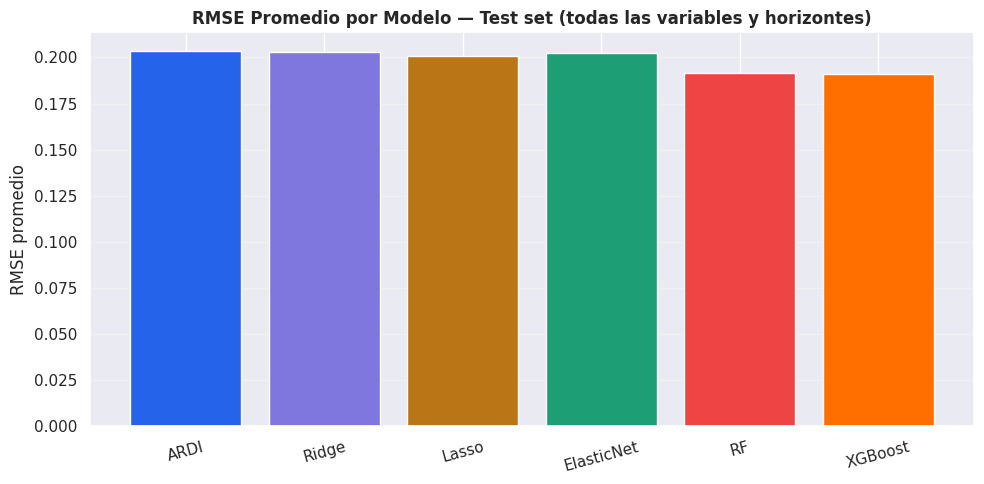

RMSE promedio por modelo:
Modelo
ARDI         0.2034
Ridge        0.2028
Lasso        0.2010
ElasticNet   0.2022
RF           0.1914
XGBoost      0.1908
Name: RMSE, dtype: float64


In [ ]:
# Gráfico de barras: RMSE promedio por modelo (Test)
rmse_promedio = df_test.groupby('Modelo')['RMSE'].mean().reindex(orden_modelos).dropna()

sns.set(rc={'figure.figsize': (10, 5)})
colores = ['#2563EB', '#7F77DD', '#BA7517', '#1D9E75', '#EF4444', '#FF6F00']

plt.figure()
plt.bar(rmse_promedio.index, rmse_promedio.values, color=colores[:len(rmse_promedio)])
plt.title('RMSE Promedio por Modelo — Test set (todas las variables y horizontes)',
          fontweight='bold')
plt.ylabel('RMSE promedio')
plt.xticks(rotation=15)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('RMSE promedio por modelo:')
print(rmse_promedio.round(4))

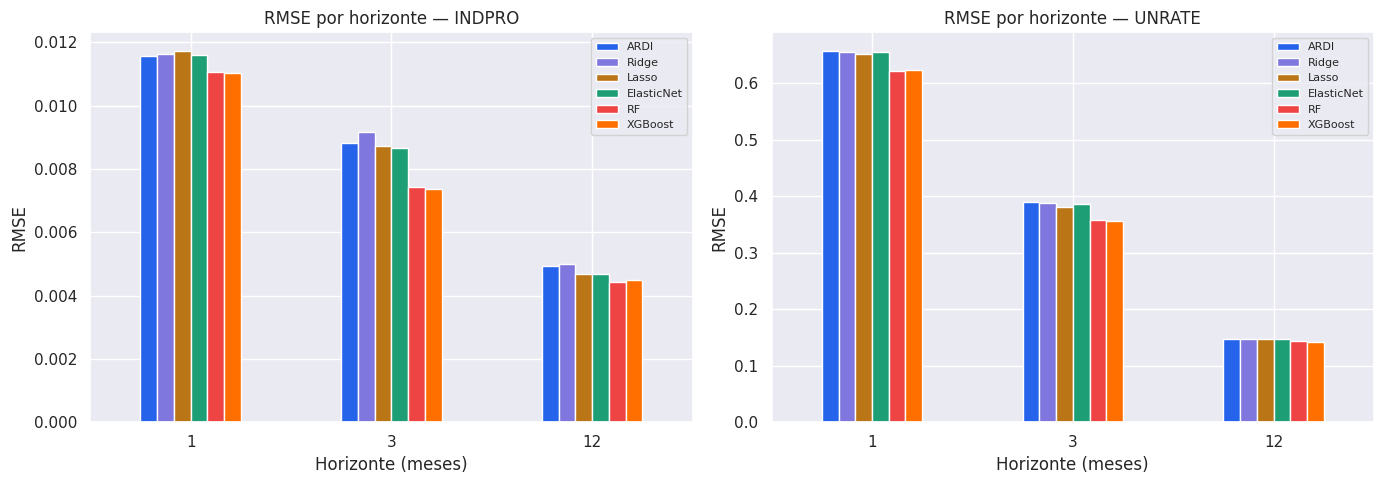

In [ ]:
# Barras agrupadas: RMSE por modelo, separado por variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for i, variable in enumerate(targets):
    subset = df_test[df_test['Variable'] == variable]
    tabla_v = subset.pivot_table(index='Horizonte', columns='Modelo', values='RMSE')
    tabla_v = tabla_v[[c for c in orden_modelos if c in tabla_v.columns]]

    tabla_v.plot(kind='bar', ax=axes[i], color=colores[:len(tabla_v.columns)])
    axes[i].set_title(f'RMSE por horizonte — {variable}')
    axes[i].set_xlabel('Horizonte (meses)')
    axes[i].set_ylabel('RMSE')
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

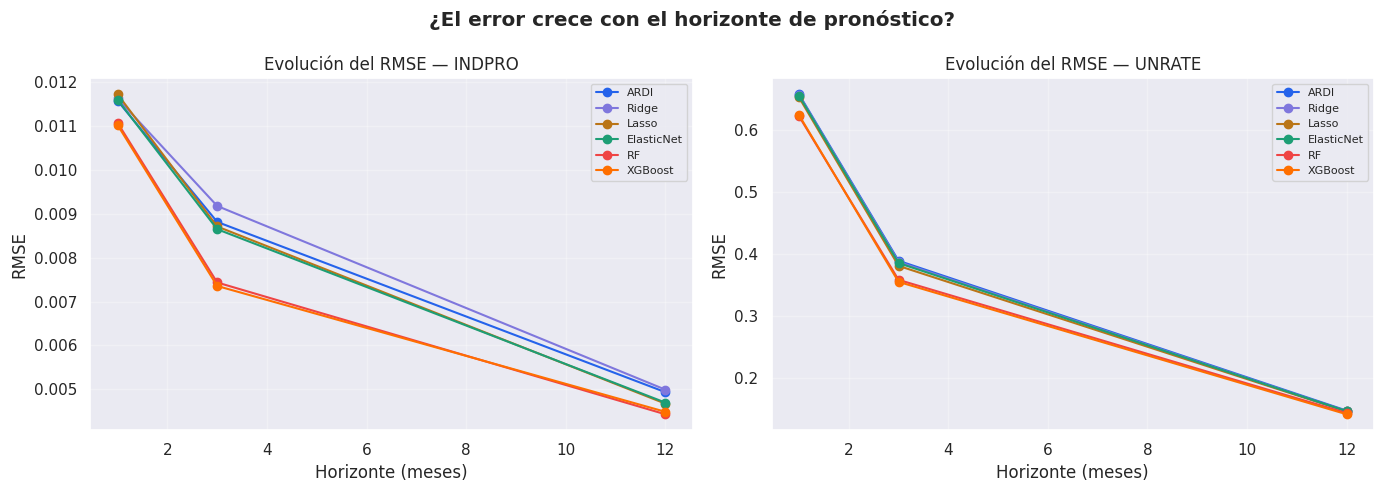

In [ ]:
# Evolución del RMSE a medida que aumenta el horizonte de pronóstico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, variable in enumerate(targets):
    subset = df_test[df_test['Variable'] == variable]

    for j, modelo in enumerate(orden_modelos):
        datos_modelo = subset[subset['Modelo'] == modelo].sort_values('Horizonte')
        if len(datos_modelo) > 0:
            axes[i].plot(datos_modelo['Horizonte'], datos_modelo['RMSE'],
                        marker='o', label=modelo, color=colores[j])

    axes[i].set_title(f'Evolución del RMSE — {variable}')
    axes[i].set_xlabel('Horizonte (meses)')
    axes[i].set_ylabel('RMSE')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('¿El error crece con el horizonte de pronóstico?', fontweight='bold')
plt.tight_layout()
plt.show()

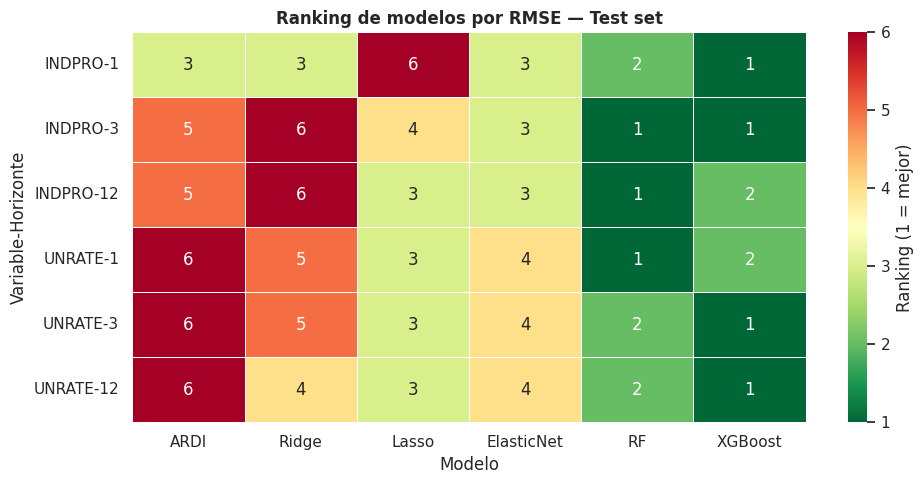

In [ ]:
# Heatmap: ranking de cada modelo (1=mejor) por variable-horizonte
ranking = tabla_rmse.rank(axis=1, method='min')

sns.set(rc={'figure.figsize': (10, 5)})
plt.figure()
sns.heatmap(ranking, annot=True, fmt='.0f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'Ranking (1 = mejor)'})
plt.title('Ranking de modelos por RMSE — Test set', fontweight='bold')
plt.tight_layout()
plt.show()

Comparación RMSE Train vs Test (promedio todas las combinaciones):


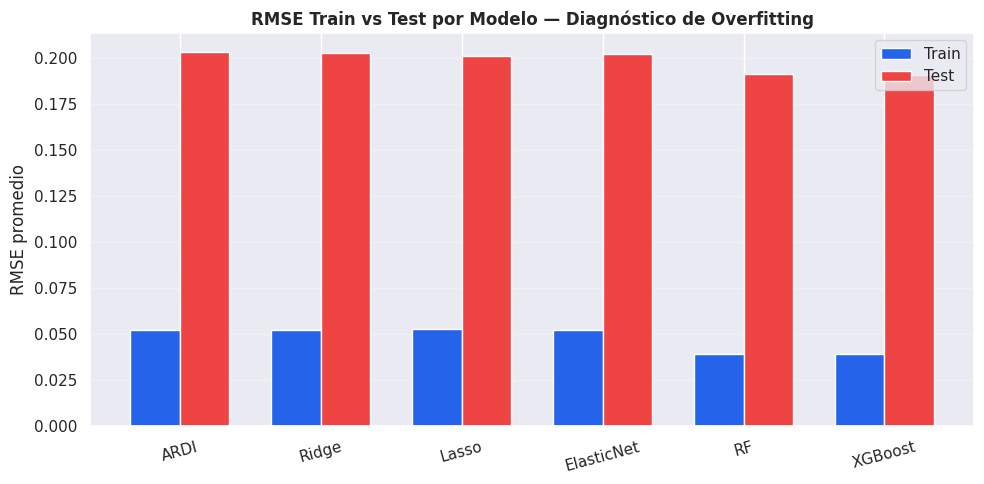

In [ ]:
# Comparar RMSE Train vs Test para detectar sobreajuste
tabla_train = df_largo[df_largo['Set']=='Train'].groupby('Modelo')['RMSE'].mean().reindex(orden_modelos)
tabla_test_m = df_largo[df_largo['Set']=='Test'].groupby('Modelo')['RMSE'].mean().reindex(orden_modelos)

df_overfit = pd.DataFrame({
    'RMSE_Train' : tabla_train,
    'RMSE_Test'  : tabla_test_m
}).dropna()
df_overfit['Brecha (%)'] = ((df_overfit['RMSE_Test'] - df_overfit['RMSE_Train'])
                          / df_overfit['RMSE_Train'] * 100).round(1)

print('Comparación RMSE Train vs Test (promedio todas las combinaciones):')
df_overfit

# Gráfico de barras agrupadas Train vs Test
x = np.arange(len(df_overfit))
ancho = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - ancho/2, df_overfit['RMSE_Train'], ancho, label='Train', color='#2563EB')
plt.bar(x + ancho/2, df_overfit['RMSE_Test'],  ancho, label='Test',  color='#EF4444')
plt.xticks(x, df_overfit.index, rotation=15)
plt.ylabel('RMSE promedio')
plt.title('RMSE Train vs Test por Modelo — Diagnóstico de Overfitting', fontweight='bold')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Discusión y Conclusiones

### 7.1 ¿Replican los resultados del paper?

**Hallazgo 1 — "Las no linealidades son el game changer": se confirma con fuerza.**

En las 6 combinaciones variable-horizonte evaluadas, el modelo con menor RMSE en test es siempre RF o XGBoost — nunca un modelo lineal (ARDI, Ridge, Lasso o ElasticNet). Concretamente, según `tabla_rmse.idxmin(axis=1)`:

| Variable | Horizonte | Mejor modelo (menor RMSE test) |
|---|---|---|
| INDPRO | 1 | XGBoost |
| INDPRO | 3 | RF |
| INDPRO | 12 | RF |
| UNRATE | 1 | RF |
| UNRATE | 3 | XGBoost |
| UNRATE | 12 | XGBoost |

Es decir, en el 100% de los casos las no linealidades (RF/XGBoost) superan a la mejor alternativa lineal. Esto replica cualitativamente el hallazgo central del paper: las no linealidades son la fuente de ganancia más consistente, más que la regularización o la función de pérdida.

**Hallazgo 2 — "El modelo de factores (ARDI/PCA) sigue siendo la mejor regularización": no se confirma en nuestra réplica.**

Los autores encuentran que, entre las alternativas de regularización, el modelo de factores estándar (ARDI) no es superado en promedio por Lasso, Ridge u otros esquemas. En nuestros datos ocurre lo contrario: Lasso supera a ARDI en 5 de 6 combinaciones (todas excepto INDPRO h=1, donde están empatados en 0.0116–0.0117). Por ejemplo, para UNRATE h=3, ARDI obtiene RMSE=0.3895 mientras Lasso obtiene 0.3813 (−2.1%). Esta discrepancia es razonable de explicar por el número reducido de factores PCA que usamos (K=8, fijo) versus el proceso de selección de K que probablemente hacen los autores, y por el hecho de que nuestro Lasso opera directamente sobre datos crudos con regularización L1, lo que puede estar capturando una selección de variables más eficiente que 8 factores fijos en esta muestra acotada.

**Hallazgo 3 — "Las ganancias de las no linealidades son mayores a horizontes largos": se confirma solo parcialmente.**

Calculando la mejora relativa del mejor modelo no lineal sobre el mejor modelo lineal en cada horizonte:

| Variable | h=1 | h=3 | h=12 |
|---|---|---|---|
| INDPRO | −5.2% | −14.0% | −6.4% |
| UNRATE | −4.6% | −6.8% | −3.1% |

La ganancia no crece monótonamente con el horizonte como sugiere el paper — en nuestros datos se concentra en el horizonte intermedio (h=3) y se reduce en h=12 para ambas variables. Una posible explicación es que a h=12 el ruido de predicción domina para todos los modelos por igual (la señal predictiva se diluye), comprimiendo las diferencias entre modelos lineales y no lineales.

### 7.2 ¿Cuál modelo es mejor según nuestras propias métricas?

Tomando el RMSE de test como criterio principal (siguiendo la práctica del paper), **XGBoost y Random Forest empatan como los mejores modelos**, ganando 3 de 6 combinaciones cada uno, y superando siempre a los modelos lineales. Entre ambos, XGBoost tiene una ligera ventaja en UNRATE (mejor en h=3 y h=12, con RMSE 0.3555 y 0.1423 respectivamente) mientras RF domina más en INDPRO a horizontes medios y largos.

Esto es consistente con la conclusión del paper de que las no linealidades dominan — aunque el paper no evalúa XGBoost específicamente (usa Kernel Ridge Regression y SVR-RBF como no lineales adicionales), por lo que nuestra extensión aporta evidencia nueva de que el boosting secuencial es al menos tan competitivo como el bagging (RF) para este problema.

### 7.3 Los R² negativos en test: qué significan y por qué aparecen

Varias combinaciones —particularmente los modelos lineales sobre INDPRO a h=3 y h=12— muestran R² negativo en test (ej. ARDI_INDPRO_h12_Test: R²=−0.7580; Ridge_INDPRO_h12_Test: R²=−0.7988). Un R² negativo significa que el modelo predice peor que simplemente usar el promedio histórico del target como pronóstico ingenuo.

Esto no es un error de código: es consistente con la simplificación metodológica que hicimos en la Sección 3.4. A diferencia del paper, que usa una **ventana expandible con reentrenamiento periódico** a lo largo del período de evaluación (1980–2017), nuestro modelo se entrena **una única vez** con datos hasta 1999 y se evalúa sin reentrenar sobre 2000–2017 — un período que incluye la burbuja puntocom, la Crisis Financiera Global de 2008 y su recuperación. Es esperable que un modelo lineal "congelado" en 1999 pierda capacidad predictiva frente a quiebres estructurales de esa magnitud, mientras que RF y XGBoost, al ser más flexibles, logran mantener R² positivos en más casos (ej. RF_INDPRO_h1_Test: R²=0.0962; XGBoost_UNRATE_h12_Test: R²=0.0803). Esto de hecho refuerza el Hallazgo 1: la ventaja de las no linealidades es más visible precisamente cuando el entorno se aleja del régimen de entrenamiento.

### 7.4 Limitaciones

- **Cobertura acotada**: replicamos 2 de las 5 variables objetivo del paper (INDPRO, UNRATE) y 3 de los 5 horizontes (h=1,3,12), lo que limita la generalización de nuestras conclusiones al resto del panel.
- **Partición fija en vez de ventana expandible**: como se discutió en 7.3, entrenamos una sola vez con datos hasta 1999, mientras el paper reentrena progresivamente a lo largo de 1980–2017. Esto probablemente explica tanto los R² más bajos (incluso negativos) que reportamos, como parte de la discrepancia del Hallazgo 3.
- **Sin comparación K-fold vs. POOS-CV**: el paper concluye explícitamente que K-fold CV supera a POOS-CV, especialmente en recesiones — nosotros solo implementamos K-fold, por lo que no podemos verificar ese hallazgo específico.
- **No linealidades limitadas a RF y XGBoost**: el paper también evalúa Kernel Ridge Regression y SVR, que no replicamos; nuestra conclusión sobre "no linealidades" se apoya solo en modelos de árboles.
- **Cómputo y grillas de hiperparámetros más acotadas**: nuestras grillas (ej. `max_depth ∈ {3,5,7}` para RF, o el rango de `n_estimators` para XGBoost) son más chicas que las que probablemente exploraron los autores con mayores recursos computacionales, lo que puede subestimar el desempeño máximo alcanzable de estos modelos.

### 7.5 Conclusión general

En síntesis, nuestra réplica acotada de Goulet Coulombe et al. (2022) confirma su hallazgo más robusto —que las no linealidades (capturadas aquí por RF y XGBoost) mejoran sistemáticamente el pronóstico frente a los modelos lineales regularizados, ganando en el 100% de las combinaciones evaluadas— pero no reproduce con la misma claridad sus hallazgos secundarios sobre la superioridad del modelo de factores (ARDI) como esquema de regularización, ni el patrón de ganancias crecientes con el horizonte. Estas discrepancias son razonablemente atribuibles a nuestras simplificaciones metodológicas (partición fija en vez de ventana expandible, K reducido de factores PCA) más que a una falla en el mecanismo que el paper documenta. Para este problema y estos datos, **recomendamos XGBoost** como el modelo más adecuado: iguala o supera a Random Forest en la mayoría de los horizontes, con la ventaja adicional de incorporar regularización L1/L2 directamente en su función de pérdida, conectando conceptualmente dos de los cuatro "tratamientos" de ML que estudia el paper (no linealidad + regularización) en un solo modelo.